In [1]:
import optuna
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/rice.csv")

df

,Date,price
0,2000-01-01 00:00:00,166.9
1,2000-02-01 00:00:00,166.0
2,2000-03-01 00:00:00,166.6
3,2000-04-01 00:00:00,169.9
4,2000-05-01 00:00:00,171.0
...,...,...
277,2023-02-01 00:00:00,175.6
278,2023-03-01 00:00:00,175.4
279,2023-04-01 00:00:00,176.2
280,2023-05-01 00:00:00,177.2


Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    282.000000
mean     187.863475
std       32.500295
min      147.600000
25%      164.800000
50%      172.650000
75%      207.250000
max      256.500000
Name: price, dtype: float64


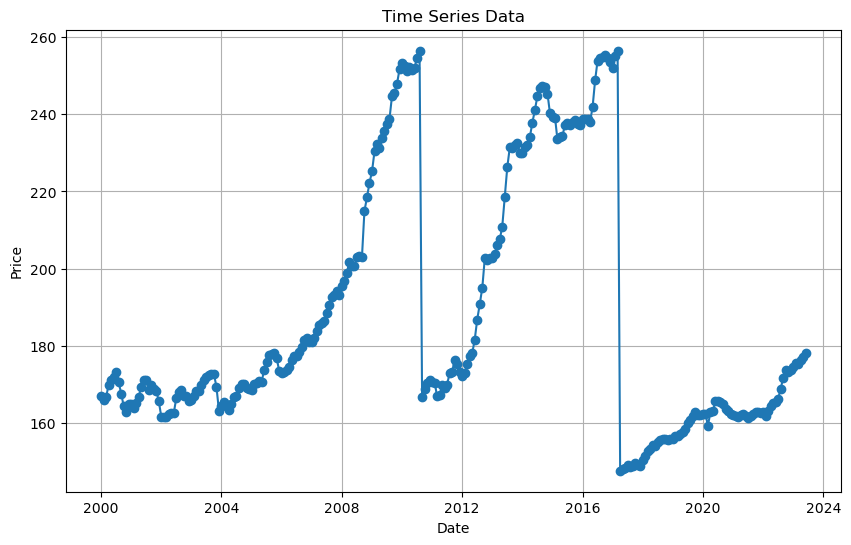

In [3]:
import pandas as pd


# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# Check basic statistics of the 'Price' column
print("\nBasic statistics of Price:")
print(df['price'].describe())

# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


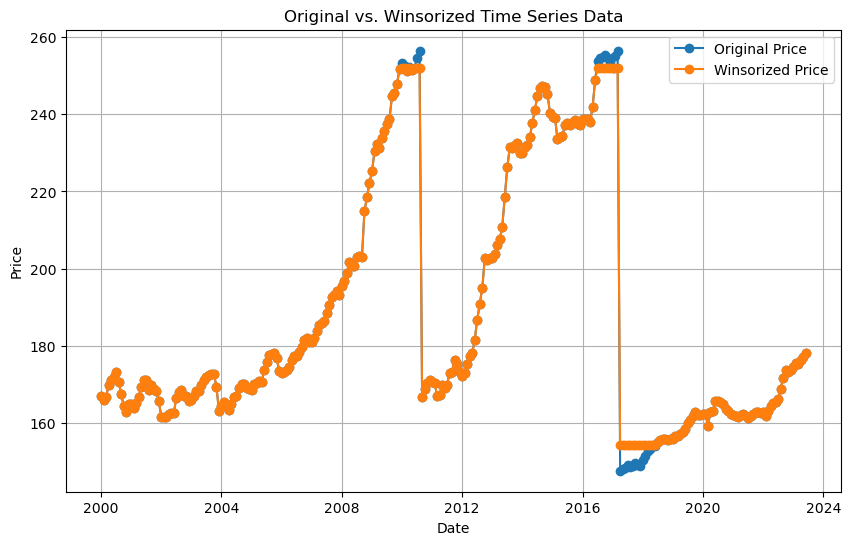

In [4]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
'''from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition
result = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months
detrended = df['price1'] - result.trend
seasonal = result.seasonal
residual = result.resid'''


"from statsmodels.tsa.seasonal import seasonal_decompose\n\n# Seasonal decomposition\nresult = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months\ndetrended = df['price1'] - result.trend\nseasonal = result.seasonal\nresidual = result.resid"

In [14]:
'''from sklearn.preprocessing import PowerTransformer

# Log transformation
df['Price_log'] = np.log(df['price1'])

# Box-Cox transformation
boxcox_transformer = PowerTransformer(method='box-cox')
df['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))

# Quantile transformation (e.g., Gaussian transformation)
quantile_transformer = PowerTransformer(method='yeo-johnson')
df['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))
'''

"from sklearn.preprocessing import PowerTransformer\n\n# Log transformation\ndf['Price_log'] = np.log(df['price1'])\n\n# Box-Cox transformation\nboxcox_transformer = PowerTransformer(method='box-cox')\ndf['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n\n# Quantile transformation (e.g., Gaussian transformation)\nquantile_transformer = PowerTransformer(method='yeo-johnson')\ndf['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n"

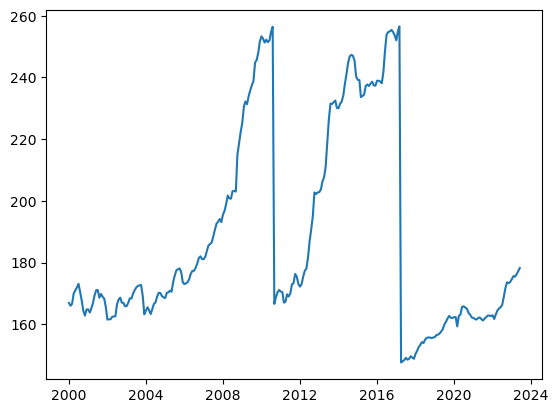

In [6]:
plt.plot(df['Date'],df['price'])

<Axes: >

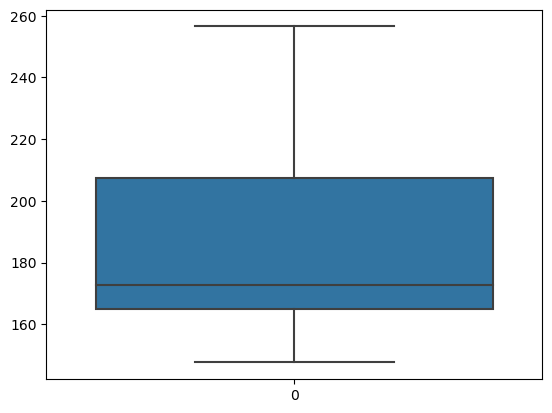

In [7]:
sn.boxplot(df['price'])

In [8]:
t=kpss(df['price'],'ct')
t

/var/folders/35/vcbg9sn9479dqrdl_3fgrrkh0000gn/T/ipykernel_85140/1514378212.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  t=kpss(df['price'],'ct')


(0.3404004465342978,
 0.01,
 10,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

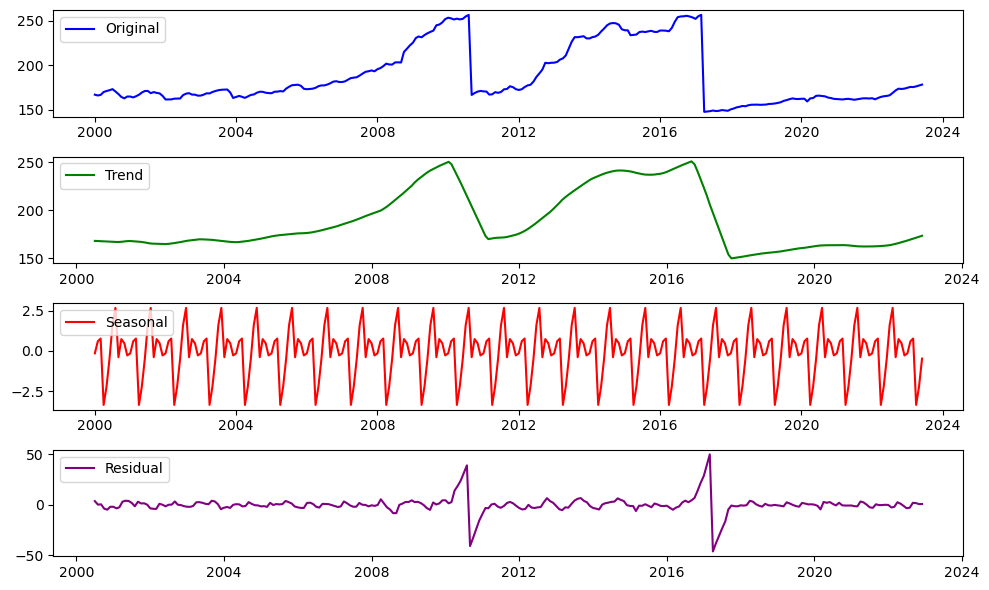

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [11]:
from scipy.stats import skew, kurtosis, shapiro

#df=pd.read_csv("DATA/Backup/rice.csv")

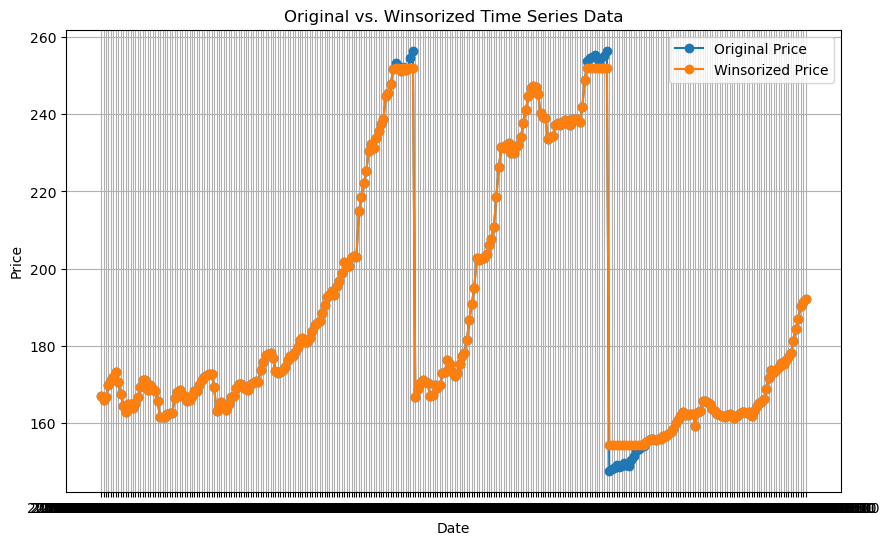

In [8]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df


,Date,price,price1
0,2000-01-01 00:00:00,166.9,166.9
1,2000-02-01 00:00:00,166.0,166.0
2,2000-03-01 00:00:00,166.6,166.6
3,2000-04-01 00:00:00,169.9,169.9
4,2000-05-01 00:00:00,171.0,171.0
...,...,...,...
283,2023-08-01 00:00:00,184.3,184.3
284,2023-09-01 00:00:00,187.0,187.0
285,2023-10-01 00:00:00,190.2,190.2
286,2023-11-01 00:00:00,191.4,191.4


In [106]:
#df.pop('price')
#df['price']=df.pop('price1')
df1=df
df1

,Date,price
0,2000-01-01 00:00:00,166.9
1,2000-02-01 00:00:00,166.0
2,2000-03-01 00:00:00,166.6
3,2000-04-01 00:00:00,169.9
4,2000-05-01 00:00:00,171.0
...,...,...
283,2023-08-01 00:00:00,184.3
284,2023-09-01 00:00:00,187.0
285,2023-10-01 00:00:00,190.2
286,2023-11-01 00:00:00,191.4


In [13]:
skewness = skew(df['price'])
kurt = kurtosis(df['price'])

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_p_value = shapiro(df['price'])

# Print the results
print("Skewness:", skewness)
print("Kurtosis:", kurt)
print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p_value)

Skewness: 0.9062133854640201
Kurtosis: -0.6908483852913809
Shapiro-Wilk Statistic: 0.8249176740646362
Shapiro-Wilk p-value: 3.666893971553287e-17


In [14]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns

scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
#import matplotlib.pyplot as plt
#plt.plot(df['Date'],df['price'])


    

#dates_test, X_test, y_test = dates[q_80:], X[q_80:], y[q_80:]

#df['target-1'] = df['price'].shift(1)
#df['target-2'] = df['price'].shift(2)
#df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)

In [10]:
#y

In [11]:
#dates
#X
#y

In [4]:
df=pd.read_csv("DATA/Backup/rice.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
shift=1
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

def objective(trial):
    # Define hyperparameters to tune
    lstm_units = trial.suggest_int('lstm_units', 32, 256)
    #gru_units = trial.suggest_int('gru_units', 32, 256)
    #num_filters = trial.suggest_int('num_filters', 16, 128)
    #kernel_size = trial.suggest_int('kernel_size', 3, 7)
    dense_units = trial.suggest_int('dense_units', 16, 128)
    #num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 3)
    learning_rate = trial.suggest_categorical('learning_rate', [1e-5, 1e-4, 1e-3])

    # Construct the model
    model = Sequential([
        layers.Input((shift, 1)),
        layers.LSTM(lstm_units),
        #layers.Bidirectional(layers.LSTM(lstm_units)),
        #layers.GRU(gru_units),
        #layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
        #layers.MaxPooling1D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dense(1)
    ])
    '''model = Sequential()
    model.add(layers.Input((1, 1)))
    for _ in range(num_lstm_layers):
        model.add(layers.LSTM(lstm_units, return_sequences=True))
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))'''
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    # Compile the model
    model.compile(loss='mse', 
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['mean_absolute_error'])

    # Train the model
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200,callbacks=[early_stopping])

    # Evaluate the model on the validation set and return the validation loss
    loss = model.evaluate(X_val, y_val)[0]
    return loss


In [6]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2024-03-12 11:27:54,965] A new study created in memory with name: no-name-dd3a5962-1781-4fc6-b568-b49ab06b1fdb


Epoch 1/200
8/8 [==============================] - 1s 26ms/step - loss: 0.2560 - mean_absolute_error: 0.4067 - val_loss: 0.0163 - val_mean_absolute_error: 0.1258
Epoch 2/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2551 - mean_absolute_error: 0.4056 - val_loss: 0.0161 - val_mean_absolute_error: 0.1251
Epoch 3/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2541 - mean_absolute_error: 0.4047 - val_loss: 0.0159 - val_mean_absolute_error: 0.1243
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2531 - mean_absolute_error: 0.4037 - val_loss: 0.0157 - val_mean_absolute_error: 0.1236
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2522 - mean_absolute_error: 0.4027 - val_loss: 0.0155 - val_mean_absolute_error: 0.1229
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2512 - mean_absolute_error: 0.4017 - val_loss: 0.0153 - val_mean_absolute_error: 0.1222
Epoch 7/200
8/8 [================

8/8 [==============================] - 0s 2ms/step - loss: 0.1512 - mean_absolute_error: 0.2894 - val_loss: 0.0011 - val_mean_absolute_error: 0.0297
Epoch 102/200
8/8 [==============================] - 0s 3ms/step - loss: 0.1503 - mean_absolute_error: 0.2882 - val_loss: 0.0010 - val_mean_absolute_error: 0.0288
Epoch 103/200
8/8 [==============================] - 0s 2ms/step - loss: 0.1494 - mean_absolute_error: 0.2871 - val_loss: 9.9537e-04 - val_mean_absolute_error: 0.0280
Epoch 104/200
8/8 [==============================] - 0s 2ms/step - loss: 0.1484 - mean_absolute_error: 0.2860 - val_loss: 9.4494e-04 - val_mean_absolute_error: 0.0273
Epoch 105/200
8/8 [==============================] - 0s 3ms/step - loss: 0.1475 - mean_absolute_error: 0.2849 - val_loss: 8.9786e-04 - val_mean_absolute_error: 0.0266
Epoch 106/200
8/8 [==============================] - 0s 3ms/step - loss: 0.1466 - mean_absolute_error: 0.2837 - val_loss: 8.5048e-04 - val_mean_absolute_error: 0.0259
Epoch 107/200
8/8 [=

[I 2024-03-12 11:27:59,076] Trial 0 finished with value: 0.00029808803810738027 and parameters: {'lstm_units': 124, 'dense_units': 72, 'learning_rate': 1e-05}. Best is trial 0 with value: 0.00029808803810738027.


Epoch 1/200
8/8 [==============================] - 1s 26ms/step - loss: 0.2607 - mean_absolute_error: 0.4094 - val_loss: 0.0149 - val_mean_absolute_error: 0.1204
Epoch 2/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2486 - mean_absolute_error: 0.3976 - val_loss: 0.0131 - val_mean_absolute_error: 0.1125
Epoch 3/200
8/8 [==============================] - 0s 4ms/step - loss: 0.2367 - mean_absolute_error: 0.3860 - val_loss: 0.0112 - val_mean_absolute_error: 0.1041
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2254 - mean_absolute_error: 0.3745 - val_loss: 0.0095 - val_mean_absolute_error: 0.0952
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2141 - mean_absolute_error: 0.3626 - val_loss: 0.0078 - val_mean_absolute_error: 0.0859
Epoch 6/200
8/8 [==============================] - 0s 4ms/step - loss: 0.2026 - mean_absolute_error: 0.3505 - val_loss: 0.0062 - val_mean_absolute_error: 0.0763
Epoch 7/200
8/8 [================

...

Epoch 1/200
8/8 [==============================] - 1s 24ms/step - loss: 0.2348 - mean_absolute_error: 0.3843 - val_loss: 0.0051 - val_mean_absolute_error: 0.0686
Epoch 2/200
8/8 [==============================] - 0s 3ms/step - loss: 0.1584 - mean_absolute_error: 0.2989 - val_loss: 6.1497e-04 - val_mean_absolute_error: 0.0206
Epoch 3/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0826 - mean_absolute_error: 0.2033 - val_loss: 0.0166 - val_mean_absolute_error: 0.1282
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0386 - mean_absolute_error: 0.1700 - val_loss: 0.0514 - val_mean_absolute_error: 0.2264
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0349 - mean_absolute_error: 0.1650 - val_loss: 0.0459 - val_mean_absolute_error: 0.2140
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0253 - mean_absolute_error: 0.1394 - val_loss: 0.0177 - val_mean_absolute_error: 0.1325
Epoch 7/200
8/8 [============

[I 2024-03-12 11:30:54,241] Trial 98 finished with value: 0.00010353929246775806 and parameters: {'lstm_units': 230, 'dense_units': 100, 'learning_rate': 0.001}. Best is trial 82 with value: 9.397701069246978e-05.


Epoch 1/200
8/8 [==============================] - 1s 24ms/step - loss: 0.2361 - mean_absolute_error: 0.3863 - val_loss: 0.0059 - val_mean_absolute_error: 0.0744
Epoch 2/200
8/8 [==============================] - 0s 3ms/step - loss: 0.1669 - mean_absolute_error: 0.3099 - val_loss: 3.1629e-04 - val_mean_absolute_error: 0.0133
Epoch 3/200
8/8 [==============================] - 0s 3ms/step - loss: 0.1023 - mean_absolute_error: 0.2262 - val_loss: 0.0079 - val_mean_absolute_error: 0.0876
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0493 - mean_absolute_error: 0.1741 - val_loss: 0.0353 - val_mean_absolute_error: 0.1874
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0349 - mean_absolute_error: 0.1674 - val_loss: 0.0529 - val_mean_absolute_error: 0.2297
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0308 - mean_absolute_error: 0.1555 - val_loss: 0.0315 - val_mean_absolute_error: 0.1770
Epoch 7/200
8/8 [============

[I 2024-03-12 11:30:55,676] Trial 99 finished with value: 9.527804650133476e-05 and parameters: {'lstm_units': 136, 'dense_units': 99, 'learning_rate': 0.001}. Best is trial 82 with value: 9.397701069246978e-05.


Best hyperparameters: {'lstm_units': 238, 'dense_units': 103, 'learning_rate': 0.001}


In [7]:
best_params

{'lstm_units': 238, 'dense_units': 103, 'learning_rate': 0.001}

In [148]:
#best_lstm_units = best_params['lstm_units']
#best_gru_units = best_params['gru_units']
num_filters = best_params['num_filters']
kernel_size = best_params['kernel_size']
best_dense_units = best_params['dense_units']
best_learning_rate = best_params['learning_rate']
#best_num_lstm_layers = best_params['num_lstm_layers']
model = Sequential([
    layers.Input((shift, 1)),
    #layers.LSTM(best_lstm_units),
    #layers.Bidirectional(layers.LSTM(best_lstm_units)),
    #layers.GRU(64),
    layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
    layers.MaxPooling1D(),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
'''
model = Sequential()
model.add(layers.Input((1, 1)))
for _ in range(best_num_lstm_layers):
    model.add(layers.LSTM(best_lstm_units, return_sequences=True))
model.add(layers.Flatten())
model.add(layers.Dense(best_dense_units, activation='relu'))
model.add(layers.Dense(1))
'''

# Compile the final model
model.compile(loss='mse', 
                optimizer=Adam(learning_rate=best_learning_rate),
                metrics=['mean_absolute_error'])

# Train the final model on the entire training data
h=model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200)
    

Epoch 1/200
8/8 [==============================] - 0s 9ms/step - loss: 0.2007 - mean_absolute_error: 0.3513 - val_loss: 0.0015 - val_mean_absolute_error: 0.0360
Epoch 2/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0796 - mean_absolute_error: 0.2018 - val_loss: 0.0021 - val_mean_absolute_error: 0.0449
Epoch 3/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0264 - mean_absolute_error: 0.1180 - val_loss: 0.0098 - val_mean_absolute_error: 0.0982
Epoch 4/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0164 - mean_absolute_error: 0.0883 - val_loss: 0.0104 - val_mean_absolute_error: 0.1012
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0142 - mean_absolute_error: 0.0721 - val_loss: 0.0030 - val_mean_absolute_error: 0.0538
Epoch 6/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0117 - mean_absolute_error: 0.0586 - val_loss: 3.8550e-04 - val_mean_absolute_error: 0.0166
Epoch 7/200
8/8 [=============

8/8 [==============================] - 0s 2ms/step - loss: 0.0072 - mean_absolute_error: 0.0271 - val_loss: 1.2234e-04 - val_mean_absolute_error: 0.0087
Epoch 100/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0074 - mean_absolute_error: 0.0242 - val_loss: 1.4601e-04 - val_mean_absolute_error: 0.0091
Epoch 101/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0077 - mean_absolute_error: 0.0328 - val_loss: 1.2702e-04 - val_mean_absolute_error: 0.0088
Epoch 102/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0073 - mean_absolute_error: 0.0278 - val_loss: 2.0230e-04 - val_mean_absolute_error: 0.0115
Epoch 103/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0073 - mean_absolute_error: 0.0296 - val_loss: 1.2921e-04 - val_mean_absolute_error: 0.0085
Epoch 104/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0073 - mean_absolute_error: 0.0268 - val_loss: 1.3834e-04 - val_mean_absolute_error: 0.0094
Epoch 105/20

8/8 [==============================] - 0s 2ms/step - loss: 0.0074 - mean_absolute_error: 0.0268 - val_loss: 2.9993e-04 - val_mean_absolute_error: 0.0149
Epoch 198/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0071 - mean_absolute_error: 0.0277 - val_loss: 1.2507e-04 - val_mean_absolute_error: 0.0085
Epoch 199/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0072 - mean_absolute_error: 0.0269 - val_loss: 1.4267e-04 - val_mean_absolute_error: 0.0093
Epoch 200/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0070 - mean_absolute_error: 0.0250 - val_loss: 1.0824e-04 - val_mean_absolute_error: 0.0077


Training Loss: [0.006984000559896231, 0.024143148213624954]
Testing Loss: [0.00014242502220440656, 0.009426623582839966]


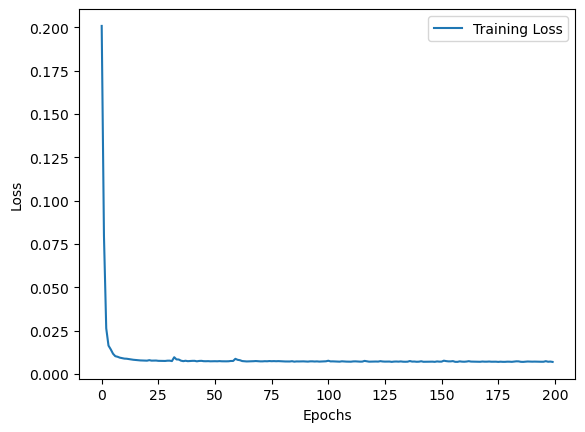

In [149]:

train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')

plt.plot(h.history['loss'], label='Training Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

8/8 [==============================] - 0s 581us/step


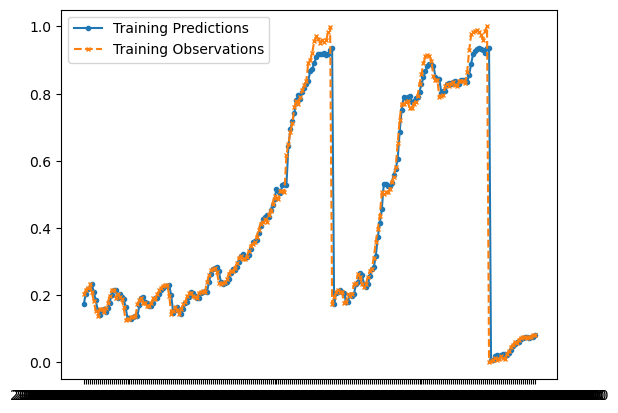

In [150]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_train, y_train, linestyle="--", marker='x', markersize=3)

##plt.plot(train_predictions)
##plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 11ms/step


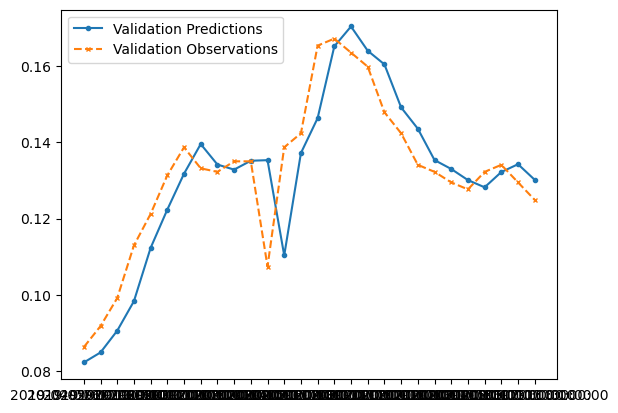

In [151]:
val_predictions = model.predict(X_val)#.flatten()

plt.plot(dates_val, val_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_val, y_val,linestyle="--", marker='x', markersize=3)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 10ms/step


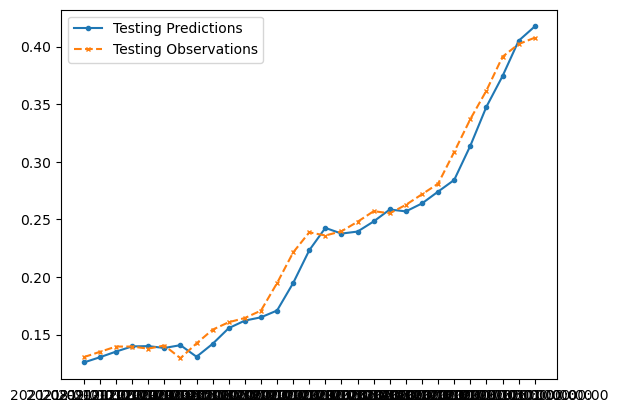

In [152]:
test_predictions = model.predict(X_test)#.flatten()

plt.plot(dates_test, test_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_test, y_test,linestyle="--", marker='x', markersize=3)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [142]:
#test_predictions

In [153]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [154]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(train_r2)
print(val_r)
print(val_r2)
print(test_r)
print(test_r2)

Training MAE: 2.6291890144348145
Training MSE: 82.82472229003906
Val MAE: 0.8423674702644348
Val MSE: 1.2836666107177734
Testing MAE: 1.026558756828308
Testing MSE: 1.6890453100204468
9.100809
0.9275509451192243
1.1329901
0.7148243612272049
1.2996328
0.9811233205161837


In [155]:
model.save('rice_cnn')

INFO:tensorflow:Assets written to: rice_cnn/assets


INFO:tensorflow:Assets written to: rice_cnn/assets


In [3]:
import tensorflow as tf
m1=tf.keras.models.load_model('rice_lstm')
m1.layers[0].input_shape

(None, 1, 1)

In [4]:
test_predictions = m1.predict(X_test)#.flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 155ms/step
0.9879600055290938


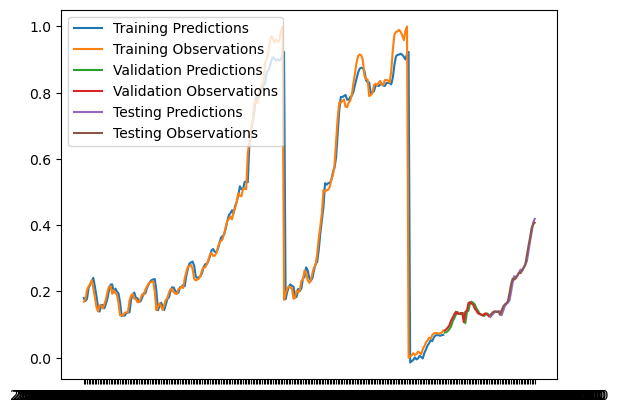

In [150]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'],loc='upper left')



In [81]:
n = 12  # Change this value to forecast more or fewer values
forecast = []
last_data = X[-1]  # Last X data point
for i in range(n):
    next_y = model.predict(last_data.reshape(1, X.shape[1], X.shape[2]))  # Predict next y
    forecast.append(next_y)
    last_data = np.append(last_data[1:], next_y)  # Shift data by 1 and append next_y
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
y_act=scaler.inverse_transform(np.array(y).reshape(-1, 1))

1/1 [==============================] - 0s 9ms/step


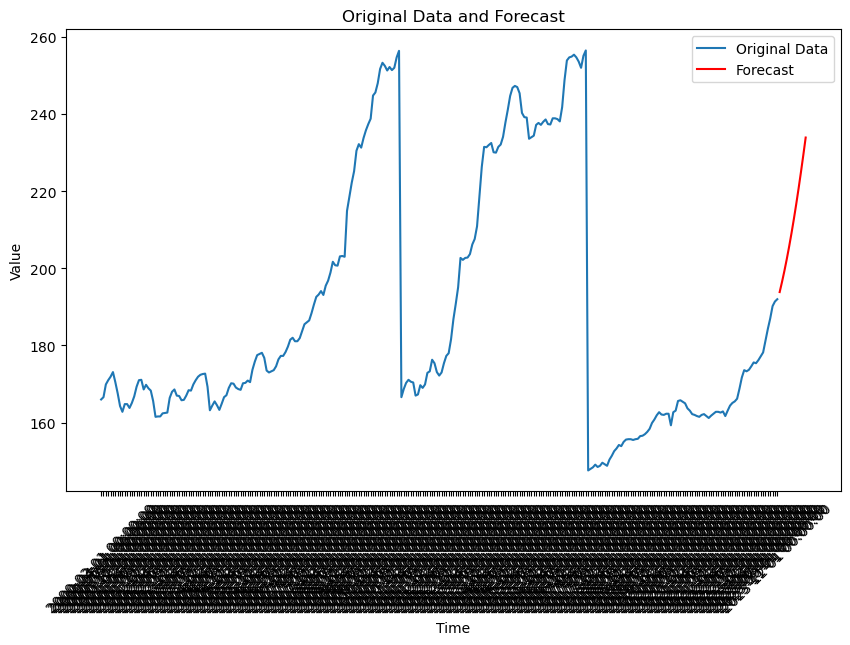

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(dates, y_act, label='Original Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data and Forecast')
plt.xticks(rotation=45)
plt.legend()

# Plot forecast
forecast_dates = np.arange(len(y), len(y) + n)
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.legend()

plt.show()